In [ ]:
import os
from pathlib import Path
from PIL import Image
from PIL.ImageFile import ImageFile
from typing import TypedDict, final

import numpy as np
import pandas as pd

from torch.utils.data import Dataset

from random import randint

from ultralytics import YOLO
from ultralytics.engine.results import Results

import cv2

from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
DATA_DIR = Path("./cv-4-objectdetection/craters/")
RESULTS_DIR = Path("./results/")

In [8]:


class CraterLabel(TypedDict):
    class_id: str
    bbox: tuple[int, int, int, int]

@final
class CraterDataset:
    def __init__(self, dir: Path):
        self.dir = dir
        self.ids = [f.stem for f in (dir / "labels").iterdir()]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx: int) -> tuple[ImageFile, list[CraterLabel]]:
        image_path = self.dir / "images" / (self.ids[idx] + ".jpg")
        image = Image.open(image_path)
        width, height = image.size

        label_path = self.dir / "labels" / (self.ids[idx] + ".txt")
        with open(label_path) as file:
            lines = file.readlines()

        labels: list[CraterLabel] = []
        for line in lines:
            class_id, *cords = line.split()
            x_center, y_center, w, h = map(float, cords)

            x_center *= width
            y_center *= height
            w *= width
            h *= height
            
            x1 = int(x_center - w/2)
            y1 = int(y_center - h/2)
            x2 = int(x_center + w/2)
            y2 = int(y_center + h/2)

            labels.append({
                "class_id" : class_id,
                "bbox" : (x1, y1, x2, y2)
            })

        return image, labels


def show_item_with_predictions(
    image,
    labels: list[CraterLabel],
    predictions: Results | None = None,
    color_label: tuple[int,int,int]=(0,255,0),
    color_pred: tuple[int,int,int]=(255,0,0),
    figsize=(10,10)
):
    if not isinstance(image, np.ndarray):
        image_cv = np.array(image)
    else:
        image_cv = image.copy()
    
    for label in labels:
        x1, y1, x2, y2 = label["bbox"]
        cv2.rectangle(image_cv, (x1, y1), (x2, y2), color_label, 2)
        cv2.putText(image_cv, f"Label {label['class_id']}", 
                    (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color_label, 1, cv2.LINE_AA)
    
    if predictions is not None:
        boxes = predictions.boxes.xyxy.cpu().numpy()
        scores = predictions.boxes.conf.cpu().numpy()
        
        for i, box in enumerate(boxes.astype(np.int32)):
            x1, y1, x2, y2 = box
            cv2.rectangle(image_cv, (x1, y1), (x2, y2), color_pred, 2)
            cv2.putText(image_cv, f"{scores[i]:.2f}", 
                        (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color_pred, 1, cv2.LINE_AA)    

    plt.figure(figsize=figsize)
    plt.axis("off")
    plt.imshow(image_cv)
    plt.show() 

def dice_score(pred_mask, true_mask):
    pred = pred_mask
    true = true_mask
    intersection = np.logical_and(pred, true).sum()
    dice = (2. * intersection) / (pred.sum() + true.sum() + 1e-8)
    return dice


In [7]:
train_dataset = CraterDataset(DATA_DIR / "train")
val_dataset = CraterDataset(DATA_DIR / "valid")

# Тренировка модели

In [ ]:
model = YOLO("yolo11s.pt")

train_results = model.train(
    data=DATA_DIR / "craters.yaml", imgsz=640, epochs=100,
    flipud=0.5,       # вертикальный флип с вероятностью 0.5
    fliplr=0.5,       # горизонтальный флип
    hsv_h=0.015,      # изменение оттенка
    hsv_s=0.7,        # насыщенность
    hsv_v=0.4,        # яркость
    degrees=10.0,     # случайный поворот
    workers=11,
    lr0=1e-3,
    lrf=0.01,
    optimizer="AdamW",
)

In [ ]:
model.save("./bestS.pt")

In [4]:
model = YOLO("./bestS.pt")

# Анализ по размеру объектов

In [9]:
categories = ["small", "medium", "large"]
thresholds = [32**2, 96**2]

def bbox_area_xyxy(bbox: tuple[int, int, int, int]) -> int:
    x1, y1, x2, y2 = bbox
    return max(0, x2 - x1) * max(0, y2 - y1)

def category_for_area(area: int) -> str:
    for i, thr in enumerate(thresholds):
        if area <= thr:
            return categories[i]
    return categories[-1]

def show_item_with_predictions(
    image,
    labels: list[CraterLabel],
    predictions: Results | None,
    categories: list[str],
    figsize=(10,10)
):
    import matplotlib.pyplot as plt

    cmap = plt.get_cmap("tab10")
    size_colors = {
        cat: tuple(int(255*c) for c in cmap(i % 10)[:3])
        for i, cat in enumerate(["small", "medium", "large"])
    }

    if not isinstance(image, np.ndarray):
        image_cv = np.array(image)
    else:
        image_cv = image.copy()

    for label in labels:
        x1, y1, x2, y2 = label["bbox"]
        cv2.rectangle(image_cv, (x1, y1), (x2, y2), (0,0,0), 2)
        cv2.putText(image_cv, f"Label {label['class_id']}",
                    (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (0,0,0), 1, cv2.LINE_AA)

    if predictions is not None:
        boxes = predictions.boxes.xyxy.cpu().numpy().astype(int)
        scores = predictions.boxes.conf.cpu().numpy()

        for i, box in enumerate(boxes):
            x1, y1, x2, y2 = box
            area = bbox_area_xyxy((x1, y1, x2, y2))
            category = category_for_area(area)
            color = size_colors.get(category, (255,255,255))

            cv2.rectangle(image_cv, (x1, y1), (x2, y2), color, 2)
            cv2.putText(image_cv, f"{category} {scores[i]:.2f}",
                        (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, color, 1, cv2.LINE_AA)

    plt.figure(figsize=figsize)
    plt.axis("off")
    plt.imshow(image_cv)
    plt.show()

def evaluate_size_bins(model: YOLO, dataset: Dataset[tuple[ImageFile, list[CraterLabel]]], categories: list[str], conf=0.5):
    dices = {name: [] for name in categories}
    counts = {name: 0 for name in categories}

    for i in range(len(dataset)):
        image, labels = dataset[i]
        width, height = image.size

        true_masks = {name: np.zeros((height, width), dtype=np.uint8) for name in categories}
        for lab in labels:
            area = bbox_area_xyxy(lab["bbox"])
            category = category_for_area(area)
            counts[category] += 1
            x1, y1, x2, y2 = lab["bbox"]
            true_masks[category][y1:y2, x1:x2] = 1

        results = model.predict(np.array(image), conf=conf, verbose=False)[0]
        pred_masks = {name: np.zeros((height, width), dtype=np.uint8) for name in categories}
        if results.boxes is not None and len(results.boxes) > 0:
            boxes = results.boxes.xyxy.cpu().numpy().astype(int)
            for box in boxes:
                x1, y1, x2, y2 = box
                area = bbox_area_xyxy((x1, y1, x2, y2))
                category = category_for_area(area)
                pred_masks[category][y1:y2, x1:x2] = 1

        for category in categories:
            if true_masks[category].sum() == 0:
                continue
            dices[category].append(dice_score(pred_masks[category], true_masks[category]))

    return dices, counts

98
(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x640 at 0x7FB0399B2650>, [{'class_id': '0', 'bbox': (284, 282, 374, 362)}])



0: 640x640 3 craters, 8.3ms
Speed: 1.0ms preprocess, 8.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


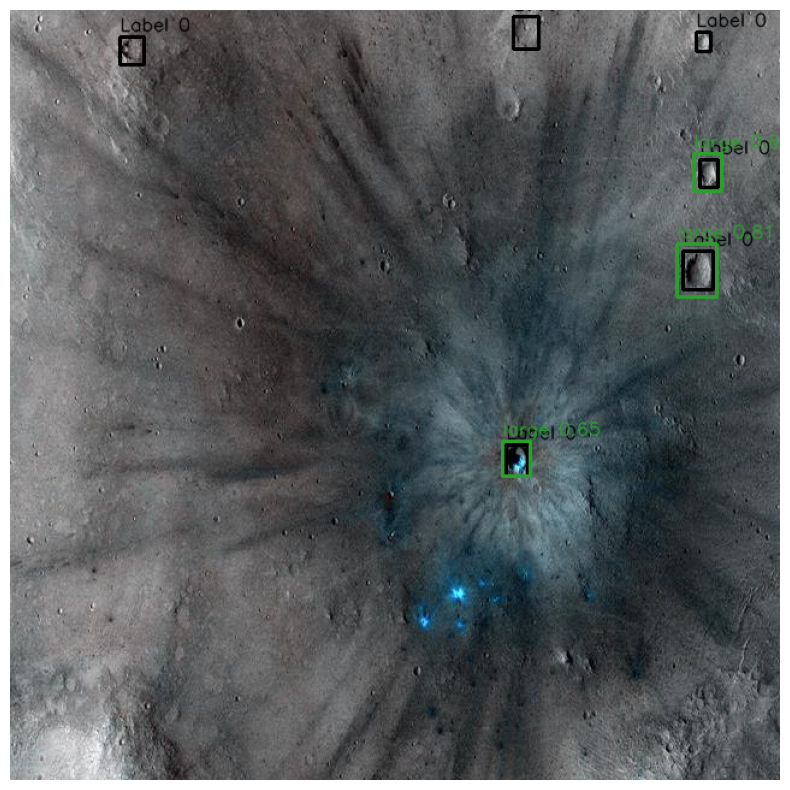

In [53]:
rand_id = randint(0, len(train_dataset) - 1)
image, labels = train_dataset[rand_id]
predictions = model.predict(np.array(image), conf=0.5)[0]
show_item_with_predictions(image, labels, predictions, categories)

In [11]:
conf = 0.5
size_dices, size_counts = evaluate_size_bins(model, val_dataset, categories, conf=conf)

print("Evaluation by size bins (mean Dice). conf =", conf)
for category in categories:
    arr = size_dices[category]
    mean_dice = float(np.mean(arr)) if len(arr) > 0 else float("nan")
    print(f"{category:6s}: gt_count={size_counts[category]:4d}, images_with_gt={len(arr):3d}, mean_dice={mean_dice:.4f}")

Evaluation by size bins (mean Dice). conf = 0.5
small : gt_count=  74, images_with_gt= 14, mean_dice=0.2572
medium: gt_count=  92, images_with_gt= 19, mean_dice=0.5414
large : gt_count=  36, images_with_gt= 16, mean_dice=0.6589


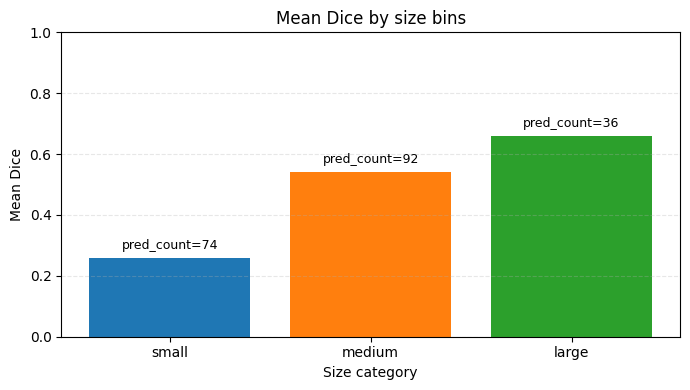

In [14]:
means = [float(np.mean(size_dices[c])) if len(size_dices[c])>0 else float("nan") for c in categories]
labels_counts = [size_counts[c] for c in categories]


plt.figure(figsize=(7,4))
cmap = plt.get_cmap("tab10")
colors = [cmap(i % 10) for i in range(len(categories))]
bars = plt.bar(categories, means, color=colors)
plt.ylim(0, 1)
plt.title("Mean Dice by size bins")
plt.ylabel("Mean Dice")
plt.xlabel("Size category")
for bar, pred_count in zip(bars, labels_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"pred_count={pred_count}", ha="center", va="bottom", fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Анализ влияния порога уверенности на метрики

In [25]:
def make_mask_for_label(width: int, height: int, labels: list[CraterLabel]):
    mask = np.zeros((width, height), dtype=np.bool)

    for label in labels:
        x1, y1, x2, y2 = label["bbox"]
        mask[y1:y2, x1:x2] = 1

    return mask

def make_mask_for_prediction(width: int, height: int, predictions: Results):
    boxes = predictions.boxes.xyxy.cpu().numpy()
    mask = np.zeros((width, height), dtype=np.bool)
    
    for i, box in enumerate(boxes.astype(np.int32)):
        x1, y1, x2, y2 = box
        mask[y1:y2, x1:x2] = 1

    return mask

def median_dice_score(model: YOLO, dataset: CraterDataset, conf: float) -> float:
    scores = []
    for id in range(len(dataset)):
        image, labels = dataset[id]
        width, height = image.size

        mask_true = make_mask_for_label(width, height, labels)

        results = model.predict(np.array(image), conf=conf, verbose=False)[0]

        mask_pred = np.zeros((height, width))
        if results.boxes is not None:
            for box in results.boxes.xyxy.cpu().numpy():
                x1, y1, x2, y2 = box.astype(int)
                mask_pred[y1:y2, x1:x2] = 1

        scores.append(dice_score(mask_pred, mask_true))

    return sum(scores) / len(scores)

In [19]:
low, high, step = 0.05, 0.95, 0.03
thresholds: list[float] = []
dice_means: list[float] = []
conf = low
while conf <= high:
    thresholds.append(conf)
    dice_means.append(median_dice_score(model, val_dataset, conf))

    conf += step

result = pd.DataFrame({"conf": thresholds, "dice_score": dice_means})

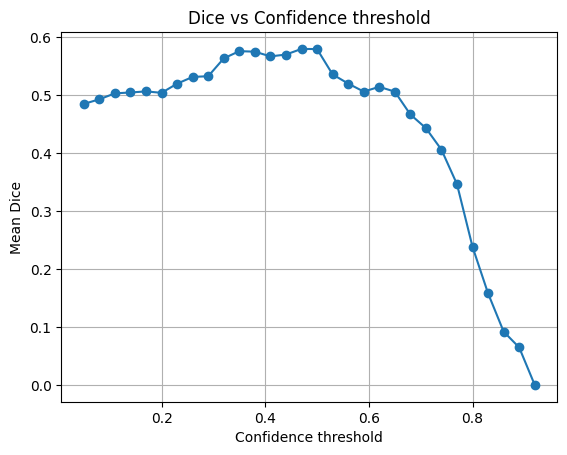

In [20]:
plt.plot(result["conf"], result["dice_score"], marker="o")
plt.title("Dice vs Confidence threshold")
plt.xlabel("Confidence threshold")
plt.ylabel("Mean Dice")
plt.grid(True)


# Генерация файла с предсказаниями

In [21]:
model = YOLO("./bestS.pt")

In [22]:
def rle_encode_tensor(mask: np.ndarray):
    """
    Encode a PyTorch binary mask tensor into Kaggle-style RLE string.

    Args:
        mask_tensor: torch.Tensor of shape (H, W) or (1, H, W)
                     dtype: bool, int, or float (will be thresholded at 0.5 if float)

    Returns:
        str: RLE string (e.g., "1 3 10 5 ...") or empty string if no foreground
    """
    # Убираем лишние измерения
    if mask.ndim == 3:
        if mask.shape[0] == 1:
            mask = mask.squeeze(0)
        else:
            raise ValueError("Expected single-channel mask, got shape: {}".format(mask.shape))

    # Бинаризуем, если нужно
    if mask.dtype == np.float32 or mask.dtype == np.float64:
        mask = mask > 0.5
    else:
        mask = mask.astype(bool)

    # Проверка на пустую маску
    if mask.sum() == 0:
        return ""

    # RLE в column-major порядке (Kaggle стандарт)
    pixels = mask.T.flatten()  # <-- ВАЖНО: .T для column-major
    pixels = np.concatenate([[0], pixels, [0]])  # паддинг
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]

    return ' '.join(str(x) for x in runs)

In [23]:
train_dir = DATA_DIR / "test" / "images"
conf = 0.25

rows = []
for image_path in train_dir.iterdir():
    image = np.array(Image.open(image_path))
    width, height, *_ = image.shape

    predictions = model(image, conf=conf)[0]
    mask = make_mask_for_prediction(width, height, predictions)

    rle_encode = rle_encode_tensor(mask)
    rows.append({
        "FILE_NAME":image_path.name, 
        "TARGET": rle_encode
    })

df = pd.DataFrame(rows).sort_values("FILE_NAME")
df.head()


0: 640x640 11 craters, 8.1ms
Speed: 1.2ms preprocess, 8.1ms inference, 5.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 8 craters, 9.1ms
Speed: 1.1ms preprocess, 9.1ms inference, 5.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 10 craters, 8.4ms
Speed: 1.2ms preprocess, 8.4ms inference, 4.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 5 craters, 8.1ms
Speed: 1.0ms preprocess, 8.1ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 11 craters, 8.3ms
Speed: 1.0ms preprocess, 8.3ms inference, 5.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 16 craters, 8.4ms
Speed: 1.1ms preprocess, 8.4ms inference, 8.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 5 craters, 8.6ms
Speed: 1.0ms preprocess, 8.6ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 6 craters, 9.0ms
Speed: 1.0ms preprocess, 9.0ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 6

,FILE_NAME,TARGET
17,010_png.rf.fcf5e274562ee69a325f9d7a0b30767f.jpg,501 101 1141 101 1781 101 2421 101 3061 101 37...
30,015_png.rf.7d5b2091b6339c9480a171a59c52c3b9.jpg,59 245 699 245 1339 245 1979 245 2619 245 3259...
1,019_png.rf.1930cd277f9bf0e3fa57f2dcfee0385f.jpg,155 197 795 197 1435 197 2075 197 2715 197 335...
12,04_png.rf.81a7d6cbeb9dc09e5a8ecd40e185fc92.jpg,11451 53 12091 53 12731 53 13371 53 14011 53 1...
15,Lunar_A_0-0_png_jpg.rf.74e92e6bd5b9fbe3cae163f...,1614 179 2254 179 2894 179 3534 179 4174 179 4...


In [24]:
df.to_csv("submishin.csv", index=False)